In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_1(Sheet1).csv to dataset_1(Sheet1).csv


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('dataset_1(Sheet1).csv')   # or your renamed file
data.head()

,I_1,I_2,I_3,I_4,I_5,I_6
0,2430000.0,3300000.0,6090000.0,2240000.0,1330000.0,443000.0
1,2440000.0,3310000.0,6120000.0,2250000.0,1340000.0,444000.0
2,2450000.0,3330000.0,6150000.0,2250000.0,1340000.0,446000.0
3,2460000.0,3340000.0,6170000.0,2260000.0,1340000.0,447000.0
4,2470000.0,3360000.0,6200000.0,2270000.0,1350000.0,448000.0


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 200

Te = np.linspace(2, 3, N)

I1 = 5*Te + np.random.normal(0,0.2,N)
I2 = 3*Te + np.random.normal(0,0.2,N)
I3 = 4*Te + np.random.normal(0,0.2,N)
I4 = 6*Te + np.random.normal(0,0.2,N)
I5 = 2*Te + np.random.normal(0,0.2,N)
I6 = 3.5*Te + np.random.normal(0,0.2,N)

data = pd.DataFrame({
    'I1': I1,
    'I2': I2,
    'I3': I3,
    'I4': I4,
    'I5': I5,
    'I6': I6,
    'Te': Te
})

data.to_csv('dataset.csv', index=False)

data.head()

,I1,I2,I3,I4,I5,I6,Te
0,10.099343,6.071557,7.681114,12.151398,4.187657,7.279871,2.000000
1,9.997473,6.127232,7.900225,11.845718,3.906841,7.202515,2.005025
2,10.179789,6.246761,8.041250,12.234223,4.039325,7.047102,2.010050
3,10.379983,6.255987,8.069698,12.361580,3.937696,6.923376,2.015075
4,10.053672,5.784768,7.990389,12.203290,3.953302,7.209996,2.020101


Dataset created
          I1        I2        I3         I4        I5        I6        Te
0  10.099343  6.071557  7.681114  12.151398  4.187657  7.279871  2.000000
1   9.997473  6.127232  7.900225  11.845718  3.906841  7.202515  2.005025
2  10.179789  6.246761  8.041250  12.234223  4.039325  7.047102  2.010050
3  10.379983  6.255987  8.069698  12.361580  3.937696  6.923376  2.015075
4  10.053672  5.784768  7.990389  12.203290  3.953302  7.209996  2.020101
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}
R2 Score: 0.992719572806514
MSE: 0.0005256566524966695


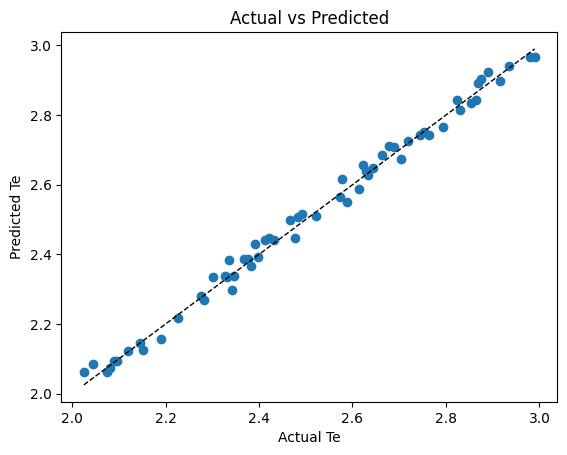

In [ ]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# =====================================
# 2. CREATE DATASET (DEPENDENT DATA)
# =====================================
np.random.seed(42)
N = 200

Te = np.linspace(2, 3, N)

I1 = 5*Te + np.random.normal(0,0.2,N)
I2 = 3*Te + np.random.normal(0,0.2,N)
I3 = 4*Te + np.random.normal(0,0.2,N)
I4 = 6*Te + np.random.normal(0,0.2,N)
I5 = 2*Te + np.random.normal(0,0.2,N)
I6 = 3.5*Te + np.random.normal(0,0.2,N)

data = pd.DataFrame({
    'I1': I1,
    'I2': I2,
    'I3': I3,
    'I4': I4,
    'I5': I5,
    'I6': I6,
    'Te': Te
})

print("Dataset created")
print(data.head())


# =====================================
# 3. PREPARE DATA
# =====================================
X = data[['I1','I2','I3','I4','I5','I6']]
y = data['Te']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# =====================================
# 4. RANDOM FOREST + TUNING
# =====================================
rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)


# =====================================
# 5. BEST MODEL
# =====================================
best_model = search.best_estimator_


# =====================================
# 6. PREDICTION
# =====================================
y_pred = best_model.predict(X_test)


# =====================================
# 7. EVALUATION
# =====================================
print("\nBest Parameters:", search.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


# =====================================
# 8. PLOT
# =====================================
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--',
         linewidth=1,
         label='y = x')
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Te")
plt.ylabel("Predicted Te")
plt.title("Actual vs Predicted")
plt.show()